In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('diabetes_risk.csv')

In [5]:
print("Shape (row, column):", df.shape)
df.head()

Shape (row, column): (15000, 19)


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [6]:
print(df.dtypes)
print()
print(df['diabetes_risk'].value_counts())
print()
print("Missing value:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicate সারি:", df.duplicated().sum())

patient_id                    int64
age                           int64
gender                          str
city                            str
bmi                         float64
family_history_diabetes         str
physical_activity_level         str
diet_type                       str
smoking_status                  str
alcohol_consumption             str
hours_sleep_per_night       float64
stress_level                  int64
fasting_blood_sugar           int64
hba1c_level                 float64
blood_pressure_systolic       int64
blood_pressure_diastolic      int64
waist_circumference_cm      float64
income_bracket                  str
diabetes_risk                   str
dtype: object

diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64

Missing value:
smoking_status          472
alcohol_consumption    3788
income_bracket          463
dtype: int64
Duplicate সারি: 0


In [7]:
df.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


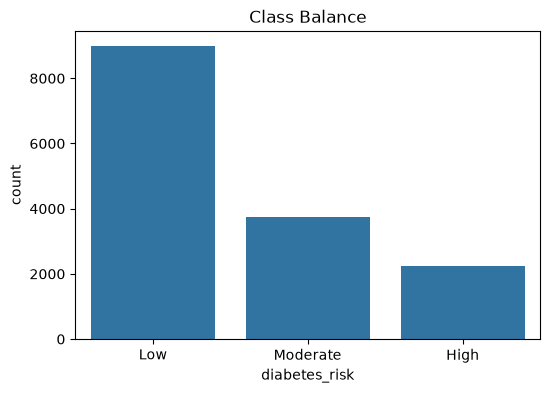

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='diabetes_risk', order=['Low','Moderate','High'])
plt.title('Class Balance'); plt.show()

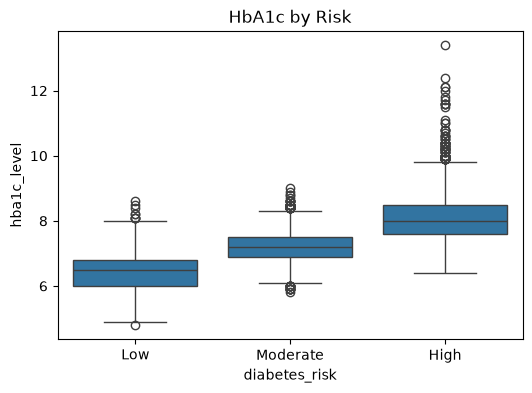

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='diabetes_risk', y='hba1c_level', order=['Low','Moderate','High'])
plt.title('HbA1c by Risk'); plt.show()

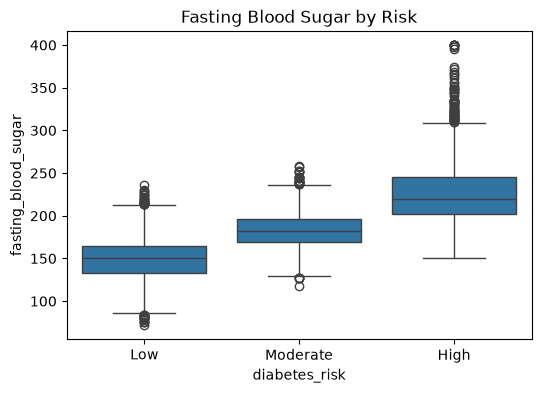

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='diabetes_risk', y='fasting_blood_sugar', order=['Low','Moderate','High'])
plt.title('Fasting Blood Sugar by Risk'); plt.show()

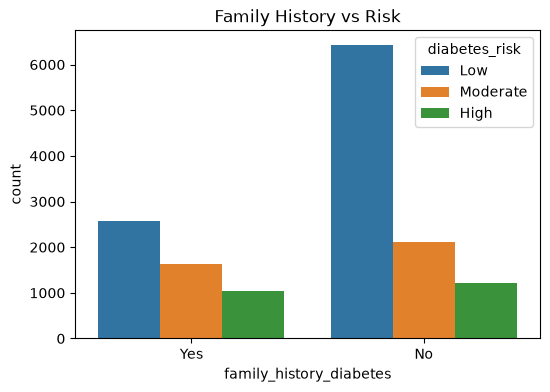

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='family_history_diabetes', hue='diabetes_risk', hue_order=['Low','Moderate','High'])
plt.title('Family History vs Risk'); plt.show()

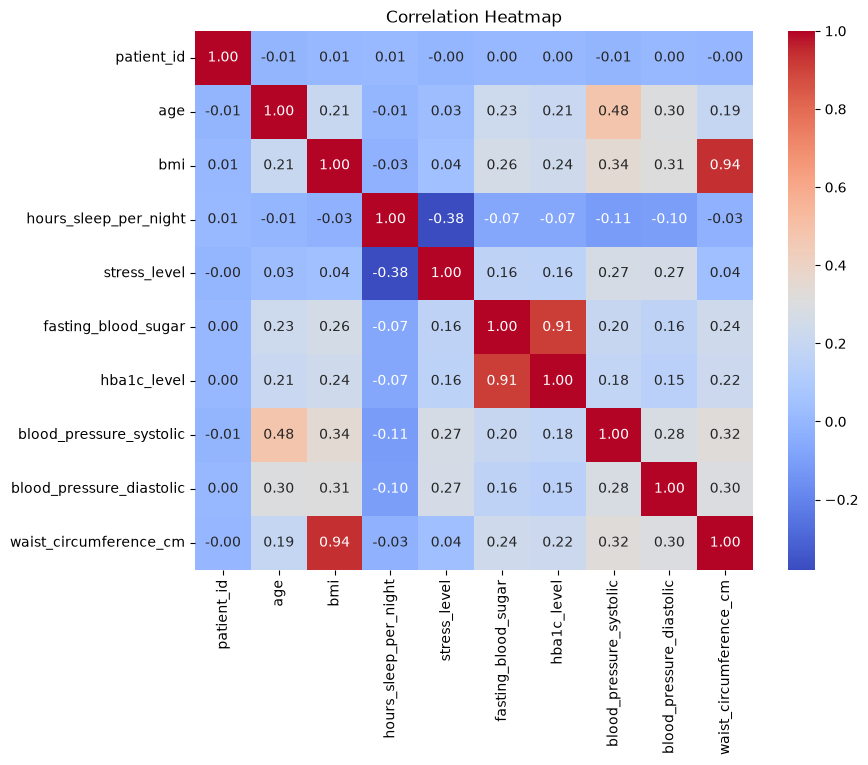

In [12]:
plt.figure(figsize=(9,7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap'); plt.show()

In [16]:
from sklearn.model_selection import train_test_split

df = df.drop(columns=['patient_id'])
df['diabetes_risk'] = df['diabetes_risk'].map({'Low':0, 'Moderate':1, 'High':2})
df['family_history_diabetes'] = df['family_history_diabetes'].map({'No':0, 'Yes':1})
df['physical_activity_level'] = df['physical_activity_level'].map({'Sedentary':0, 'Moderate':1, 'Active':2})

X = df.drop(columns=['diabetes_risk'])
y = df['diabetes_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print(y_train.value_counts(normalize=True))

Train: (12000, 17) | Test: (3000, 17)
diabetes_risk
0    0.60
1    0.25
2    0.15
Name: proportion, dtype: float64


In [17]:
missing_cols = ['smoking_status', 'alcohol_consumption', 'income_bracket']
for col in missing_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col]  = X_test[col].fillna(mode_value)

print("Train-এ missing:", X_train.isnull().sum().sum())
print("Test-এ missing :", X_test.isnull().sum().sum())

Train-এ missing: 0
Test-এ missing : 0


In [18]:
nominal_cols = ['gender', 'city', 'diet_type', 'smoking_status',
                'alcohol_consumption', 'income_bracket']

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=nominal_cols, drop_first=True)

# Test-কে Train-এর কলামের সাথে মেলাও (না থাকলে ০)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (12000, 39) | Test: (3000, 39)


In [19]:
outlier_cols = ['bmi', 'fasting_blood_sugar', 'hba1c_level',
                'blood_pressure_systolic', 'blood_pressure_diastolic',
                'waist_circumference_cm']

for col in outlier_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    X_train[col] = np.clip(X_train[col], lower, upper)
    X_test[col]  = np.clip(X_test[col],  lower, upper)
print("Outlier capping Completed")

Outlier capping Completed


In [20]:
def add_features(d):
    d = d.copy()
    d['mean_arterial_pressure'] = d['blood_pressure_diastolic'] + (
        d['blood_pressure_systolic'] - d['blood_pressure_diastolic']) / 3
    # BMI category: 0=Low weight, 1=Normal Weight, 2=High Weight, 3= Faty
    d['bmi_category'] = pd.cut(d['bmi'], bins=[-np.inf, 18.5, 25, 30, np.inf],
                               labels=[0, 1, 2, 3], right=False).astype(int)
    return d

X_train = add_features(X_train)
X_test  = add_features(X_test)
X_train[['mean_arterial_pressure', 'bmi_category']].head()

,mean_arterial_pressure,bmi_category
3489,105.333333,1
12801,94.666667,2
1186,104.000000,1
1949,111.333333,2
1571,90.666667,1


['fasting_blood_sugar', 'hba1c_level', 'age', 'waist_circumference_cm', 'bmi', 'mean_arterial_pressure', 'blood_pressure_systolic', 'hours_sleep_per_night', 'blood_pressure_diastolic', 'stress_level', 'physical_activity_level', 'bmi_category', 'family_history_diabetes', 'diet_type_Vegetarian', 'income_bracket_Middle']


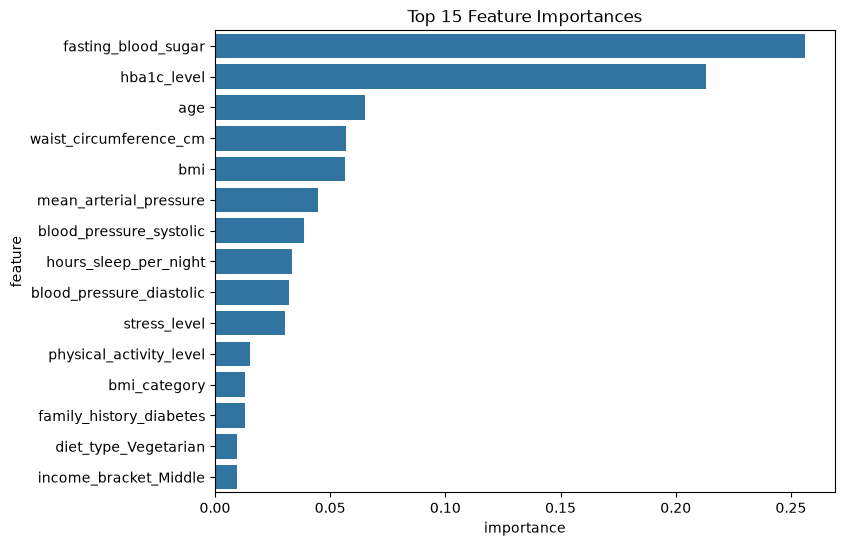

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(n_estimators=200, random_state=42)
rf_selector.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

selected_features = importance_df.head(15)['feature'].tolist()
print(selected_features)

plt.figure(figsize=(8,6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importances'); plt.show()

X_train = X_train[selected_features]
X_test  = X_test[selected_features]

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)
X_train_scaled.describe().loc[['mean','std']].round(2)

,fasting_blood_sugar,hba1c_level,age,waist_circumference_cm,bmi,mean_arterial_pressure,blood_pressure_systolic,hours_sleep_per_night,blood_pressure_diastolic,stress_level,physical_activity_level,bmi_category,family_history_diabetes,diet_type_Vegetarian,income_bracket_Middle
mean,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

print("All the THREE Models are trained")

All the THREE Models are trained


In [24]:
from sklearn.metrics import classification_report, accuracy_score

labels = ['Low','Moderate','High']
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf  = rf_model.predict(X_test)
y_pred_gb  = gb_model.predict(X_test)

for name, pred in [('Logistic Regression', y_pred_log),
                   ('Random Forest', y_pred_rf),
                   ('Gradient Boosting', y_pred_gb)]:
    print("=====", name, "=====")
    print("Accuracy:", round(accuracy_score(y_test, pred), 4))
    print(classification_report(y_test, pred, target_names=labels))

===== Logistic Regression =====
Accuracy: 0.7863
              precision    recall  f1-score   support

         Low       0.86      0.90      0.88      1800
    Moderate       0.59      0.56      0.57       750
        High       0.81      0.69      0.74       450

    accuracy                           0.79      3000
   macro avg       0.75      0.72      0.73      3000
weighted avg       0.78      0.79      0.78      3000

===== Random Forest =====
Accuracy: 0.782
              precision    recall  f1-score   support

         Low       0.85      0.90      0.88      1800
    Moderate       0.58      0.55      0.57       750
        High       0.82      0.68      0.74       450

    accuracy                           0.78      3000
   macro avg       0.75      0.71      0.73      3000
weighted avg       0.78      0.78      0.78      3000

===== Gradient Boosting =====
Accuracy: 0.786
              precision    recall  f1-score   support

         Low       0.86      0.89      0.88   

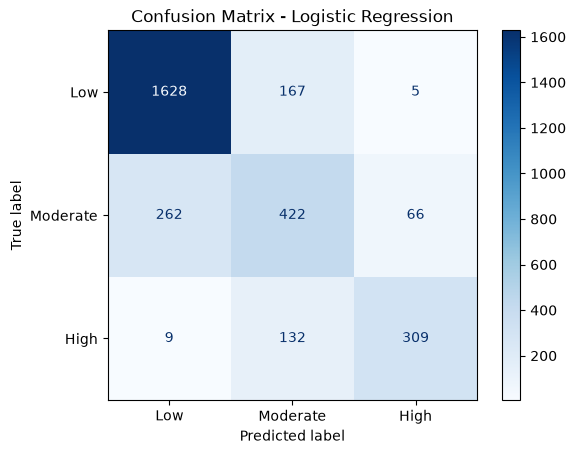

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log), display_labels=labels).plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression'); plt.show()

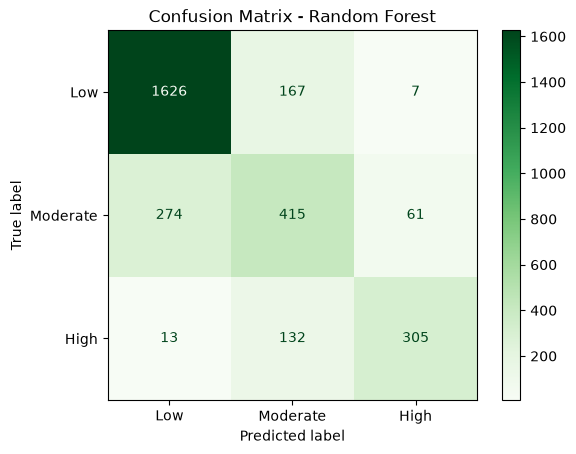

In [26]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=labels).plot(cmap='Greens')
plt.title('Confusion Matrix - Random Forest'); plt.show()

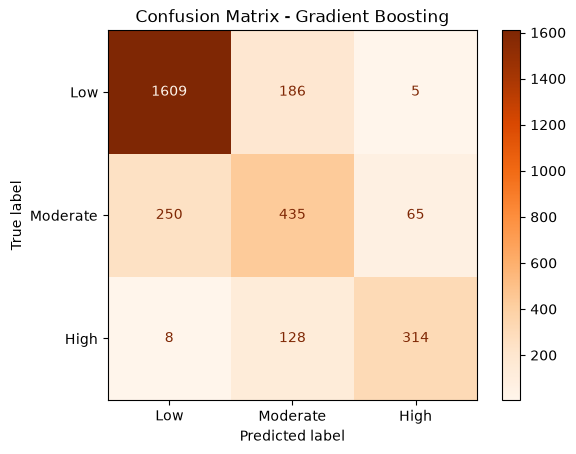

In [27]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gb), display_labels=labels).plot(cmap='Oranges')
plt.title('Confusion Matrix - Gradient Boosting'); plt.show()

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for name, pred in [('Logistic Regression', y_pred_log),
                   ('Random Forest', y_pred_rf),
                   ('Gradient Boosting', y_pred_gb)]:
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision (weighted)': precision_score(y_test, pred, average='weighted'),
        'Recall (weighted)': recall_score(y_test, pred, average='weighted'),
        'F1 (weighted)': f1_score(y_test, pred, average='weighted'),
        'F1 (macro)': f1_score(y_test, pred, average='macro')})
comparison_df = pd.DataFrame(rows).round(4)
comparison_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro)
0,Logistic Regression,0.7863,0.7827,0.7863,0.7833,0.7329
1,Random Forest,0.7820,0.7779,0.7820,0.7784,0.7280
2,Gradient Boosting,0.7860,0.7849,0.7860,0.7846,0.7370


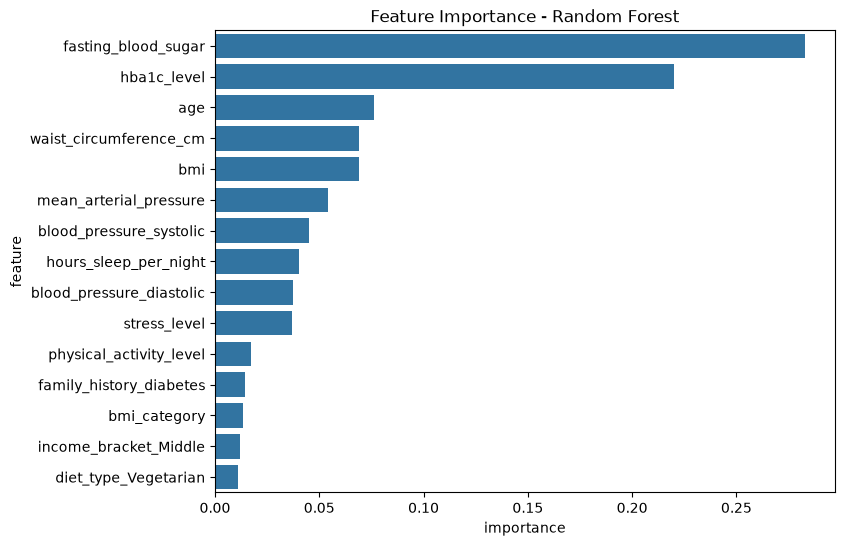

,feature,importance
0,fasting_blood_sugar,0.283100
1,hba1c_level,0.220031
2,age,0.076467
3,waist_circumference_cm,0.069212
4,bmi,0.069115
5,mean_arterial_pressure,0.054393
6,blood_pressure_systolic,0.045105
7,hours_sleep_per_night,0.040376
8,blood_pressure_diastolic,0.037288
9,stress_level,0.037040


In [29]:
final_imp = pd.DataFrame({'feature': X_train.columns,
                          'importance': rf_model.feature_importances_}
                        ).sort_values('importance', ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(data=final_imp, x='importance', y='feature')
plt.title('Feature Importance - Random Forest'); plt.show()
final_imp